# NN Value Function Training

Train a neural network to approximate the value function for the collection game.
Training data comes from expectimax search — we play games with search, record
(state, search_value) pairs, and train the NN to predict those values.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from game import GameConfig, face_score, total_score_from_table, play_game, sample_transitions
from engine import Engine
from model import ValueNet, make_leaf_fn, make_heuristic_leaf_fn, encode_states_batch, save_model, load_model, nn_get_action

In [ ]:
import torch
import torch.nn as nn

def generate_training_data(config, engine, num_games):
    """Play games with search engine, collect (state, value) training pairs."""
    data = []
    for game_i in range(num_games):
        if (game_i + 1) % max(1, num_games // 10) == 0 or game_i == 0:
            print(f"  Game {game_i + 1}/{num_games} ({len(data)} samples so far)")
        stashed = config.init_stashed
        remaining = config.init_pool
        for _round in range(config.num_rounds):
            if sum(remaining) < config.draw_size:
                break
            transitions, _, _ = sample_transitions(stashed, remaining, config)
            best_value = -1e9
            best_idx = 0
            for idx, (s, r) in enumerate(transitions):
                v = engine.search_value(s, r)
                data.append(((s, r), v))
                if v > best_value:
                    best_value = v
                    best_idx = idx
            stashed, remaining = transitions[best_idx]
    return data

def train_model(model, data, config, epochs=50, batch_size=256, lr=1e-3):
    """Train the value network on (state, value) pairs."""
    states = [d[0] for d in data]
    values = torch.tensor([d[1] for d in data], dtype=torch.float32)
    X = encode_states_batch(states, config)
    dataset = torch.utils.data.TensorDataset(X, values)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    model.train()
    loss_history = []
    for epoch in range(epochs):
        epoch_loss = 0.0
        n_batches = 0
        for xb, yb in loader:
            pred = model(xb)
            loss = loss_fn(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        loss_history.append(epoch_loss / n_batches)
    model.eval()
    return loss_history

## 1. Config — small game for fast iteration

In [3]:
small_config = GameConfig(
    num_types=5,
    init_pool=(8, 7, 6, 5, 4),  # 30 total
    draw_size=5,
    num_bundles=4,
    overlap_degree=2,
    score_fn=face_score,
)
print(f"Rounds: {small_config.num_rounds}")
print(f"Types: {small_config.num_types}, Pool: {small_config.init_pool}")
print(f"Input size: {2 * small_config.num_types}")
print("Random playthrough:")
play_game(small_config, lambda state: np.random.choice(small_config.num_bundles), verbose=True)

Rounds: 6
Types: 5, Pool: (8, 7, 6, 5, 4)
Input size: 10
Random playthrough:
  Round 1: drew [1 4 3 3 4]
           bundle 0: 3 4
           bundle 1: 1 4 3
           bundle 2: 3
           bundle 3: 1 4 3 4 >>>
  Stash:     [ 1   0   1   2   0]
  Remaining: [ 7   7   4   3   4]

  Round 2: drew [3 3 1 1 4]
           bundle 0: 3 4
           bundle 1: 3 1
           bundle 2: 3 3 1 4 >>>
           bundle 3: 1 1
  Stash:     [ 2   0   3   3   0]
  Remaining: [ 5   7   2   2   4]

  Round 3: drew [1 2 5 5 2]
           bundle 0: 5 2 >>>
           bundle 1: 5 5
           bundle 2: 1 2 2
           bundle 3: 1 2 5
  Stash:     [ 2   1   3   3   1]
  Remaining: [ 4   5   2   2   2]

  Round 4: drew [2 3 2 2 1]
           bundle 0: 2 2 2 1 >>>
           bundle 1: 2
           bundle 2: 3 2
           bundle 3: 2 3 1
  Stash:     [ 3   4   3   3   1]
  Remaining: [ 3   2   1   2   2]

  Round 5: drew [1 1 2 2 5]
           bundle 0: 2
           bundle 1: 1 2 2
           bundle 2: 1 2 

18.0

## 2. Generate training data with search

In [8]:
search_engine = Engine(depth=2, fanout=10, config=small_config)
print("Generating training data (this triggers numba compilation on first run)...")
data = generate_training_data(small_config, search_engine, num_games=5000)
print(f"Collected {len(data)} training samples")
print(f"Nodes searched: {search_engine.node_count:,}")

# Quick look at value distribution
values = [d[1] for d in data]
print(f"Value range: [{min(values):.1f}, {max(values):.1f}], mean: {np.mean(values):.1f}")

# Show an example training sample.
# The label value is the expected score returned by expectimax search from this
# state — i.e. the average over sampled future draws of the best-play score,
# looking `depth` rounds ahead. It's NOT the final game score; it's the search
# engine's estimate of how much this state is worth under optimal play.
(example_stashed, example_remaining), example_value = data[len(data) // 2]
print(f"\nExample training sample:")
print(f"  Stashed:   {example_stashed}")
print(f"  Remaining: {example_remaining}")
print(f"  Label (search value): {example_value:.2f}")

Generating training data (this triggers numba compilation on first run)...
  Game 1/5000 (0 samples so far)
  Game 500/5000 (11976 samples so far)
  Game 1000/5000 (23976 samples so far)
  Game 1500/5000 (35976 samples so far)
  Game 2000/5000 (47976 samples so far)
  Game 2500/5000 (59976 samples so far)
  Game 3000/5000 (71976 samples so far)
  Game 3500/5000 (83976 samples so far)
  Game 4000/5000 (95976 samples so far)
  Game 4500/5000 (107976 samples so far)
  Game 5000/5000 (119976 samples so far)
Collected 120000 training samples
Nodes searched: 128,820,000
Value range: [-65.0, 128.0], mean: 42.2

Example training sample:
  Stashed:   (1, 1, 1, 0, 0)
  Remaining: (7, 5, 4, 5, 4)
  Label (search value): 15.75


## 3. Train the model

Parameters: 2,497


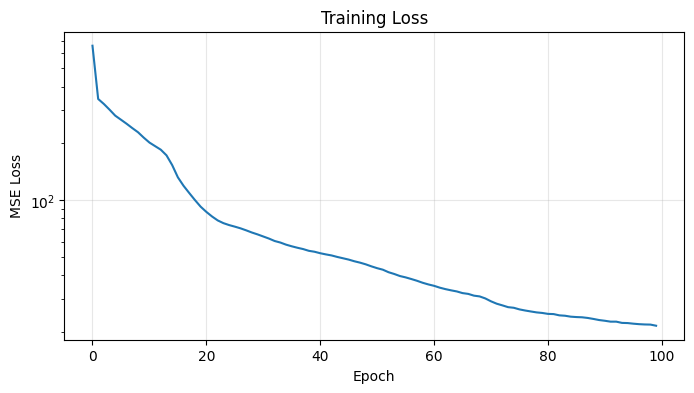

Final loss: 21.6084


In [9]:
model = ValueNet(small_config.num_types, hidden_size=32, num_layers=3)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

loss_history = train_model(model, data, small_config, epochs=100, batch_size=128, lr=1e-3)

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.show()
print(f"Final loss: {loss_history[-1]:.4f}")

### Prediction quality on held-out states

Generate fresh games with search, then compare search values to NN predictions.
The scatter shows how well the NN tracks the search engine; the residual histogram
shows the error distribution.

  Game 1/200 (0 samples so far)
  Game 20/200 (456 samples so far)
  Game 40/200 (936 samples so far)
  Game 60/200 (1416 samples so far)
  Game 80/200 (1896 samples so far)
  Game 100/200 (2376 samples so far)
  Game 120/200 (2856 samples so far)
  Game 140/200 (3336 samples so far)
  Game 160/200 (3816 samples so far)
  Game 180/200 (4296 samples so far)
  Game 200/200 (4776 samples so far)
Test samples: 4800


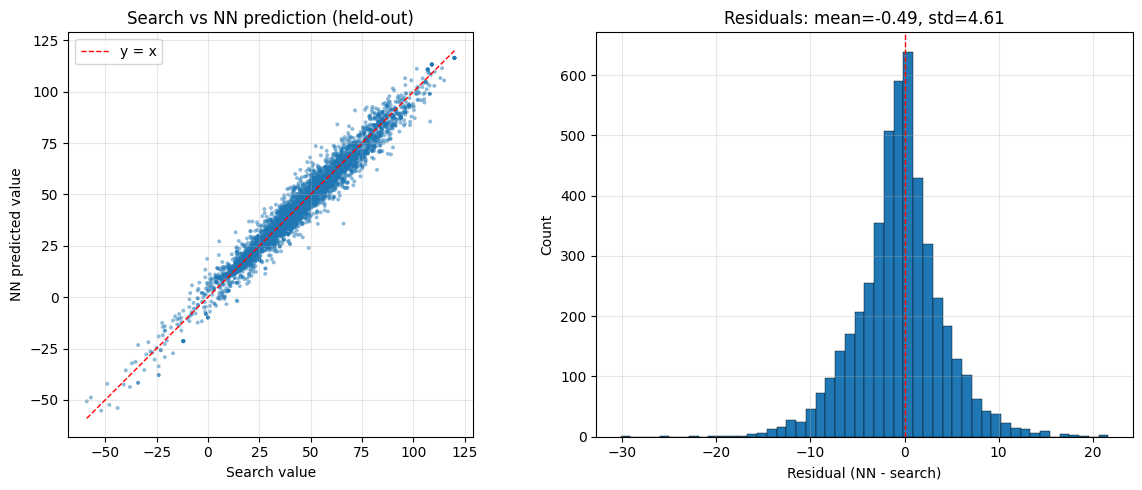

In [12]:
import torch

# Generate held-out test data
test_engine = Engine(depth=2, fanout=10, config=small_config)
test_data = generate_training_data(small_config, test_engine, num_games=200)
print(f"Test samples: {len(test_data)}")

test_states = [d[0] for d in test_data]
search_values = np.array([d[1] for d in test_data])

X_test = encode_states_batch(test_states, small_config)
with torch.no_grad():
    nn_values = model(X_test).numpy()

residuals = nn_values - search_values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: search value vs NN prediction
ax = axes[0]
ax.scatter(search_values, nn_values, alpha=0.5, s=8, edgecolors="none")
vmin, vmax = min(search_values.min(), nn_values.min()), max(search_values.max(), nn_values.max())
ax.plot([vmin, vmax], [vmin, vmax], "r--", lw=1, label="y = x")
ax.set_xlabel("Search value")
ax.set_ylabel("NN predicted value")
ax.set_title("Search vs NN prediction (held-out)")
ax.legend()
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# Residual histogram
ax = axes[1]
ax.hist(residuals, bins=50, edgecolor="black", linewidth=0.3)
ax.axvline(0, color="r", linestyle="--", lw=1)
ax.set_xlabel("Residual (NN - search)")
ax.set_ylabel("Count")
ax.set_title(f"Residuals: mean={residuals.mean():.2f}, std={residuals.std():.2f}")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Evaluate: NN vs Search vs Random

In [13]:
EVAL_DEPTH = 2
EVAL_FANOUT = 10
N_EVAL = 50

def eval_agents(config, model, n_games=N_EVAL):
    """Compare search+NN vs search+heuristic vs NN-only vs random."""
    engine_nn = Engine(EVAL_DEPTH, EVAL_FANOUT, config, leaf_fn=make_leaf_fn(model, config))
    engine_heur = Engine(EVAL_DEPTH, EVAL_FANOUT, config, leaf_fn=make_heuristic_leaf_fn(config))

    search_nn = [play_game(config, engine_nn.get_action) for _ in range(n_games)]
    search_heur = [play_game(config, engine_heur.get_action) for _ in range(n_games)]
    nn_only = [play_game(config, lambda t: nn_get_action(model, t, config)) for _ in range(n_games)]
    random_scores = [play_game(config, lambda t: np.random.randint(len(t))) for _ in range(n_games)]

    print(f"{'Agent':<25s} {'Mean':>8s} {'Std':>8s} {'Min':>8s} {'Max':>8s}")
    print("-" * 58)
    for name, scores in [
        ("Search + NN leaf", search_nn),
        ("Search + heuristic leaf", search_heur),
        ("NN only (no search)", nn_only),
        ("Random", random_scores),
    ]:
        print(f"{name:<25s} {np.mean(scores):8.1f} {np.std(scores):8.1f} {min(scores):8.1f} {max(scores):8.1f}")

    return search_nn, search_heur, nn_only, random_scores

search_nn, search_heur, nn_only, random_scores = eval_agents(small_config, model)

Agent                         Mean      Std      Min      Max
----------------------------------------------------------
Search + NN leaf              74.7     23.3     17.0    120.0
Search + heuristic leaf       73.0     24.7     21.0    120.0
NN only (no search)           74.3     28.7    -18.0    120.0
Random                         5.4     25.5    -39.0     75.0


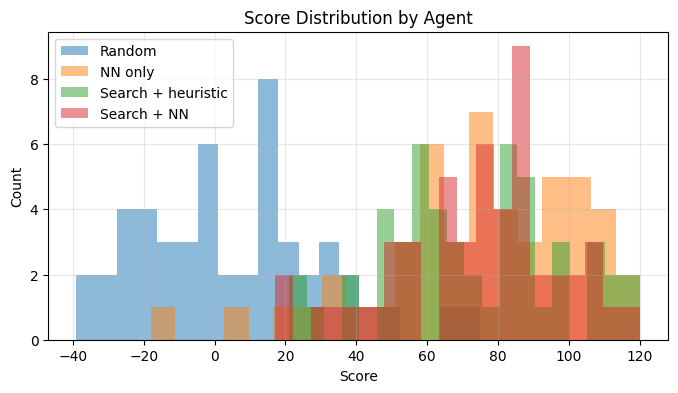

In [14]:
# Score distributions
plt.figure(figsize=(8, 4))
plt.hist(random_scores, bins=20, alpha=0.5, label="Random")
plt.hist(nn_only, bins=20, alpha=0.5, label="NN only")
plt.hist(search_heur, bins=20, alpha=0.5, label="Search + heuristic")
plt.hist(search_nn, bins=20, alpha=0.5, label="Search + NN")
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Score Distribution by Agent")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Sanity check: NN ≈ exact score at terminal states

At game end (remaining all zeros), the value is exactly `total_score_from_table`.
We play real games to collect actual final stashes, then check that the NN
gets these right.

In [ ]:
import torch
from game import sample_transitions

# Play games to completion and collect actual final stashes
empty_remaining = (0,) * small_config.num_types
score_table = small_config.make_score_table()

final_stashes = set()
action_fns = [
    lambda t: nn_get_action(model, t, small_config),
    lambda t: np.random.randint(len(t)),
]
for af in action_fns:
    for _ in range(50):
        stashed = small_config.init_stashed
        remaining = small_config.init_pool
        for _ in range(small_config.num_rounds):
            if sum(remaining) < small_config.draw_size:
                break
            transitions, _, _ = sample_transitions(stashed, remaining, small_config)
            stashed, remaining = transitions[af(transitions)]
        final_stashes.add(stashed)

final_stashes = sorted(final_stashes)

states = [(s, empty_remaining) for s in final_stashes]
X = encode_states_batch(states, small_config)
with torch.no_grad():
    nn_values = model(X).numpy()

print(f"{len(final_stashes)} unique final stashes from 100 games (NN + random)")
print(f"\n{'Stashed':<25s} {'Exact':>10s} {'NN':>10s} {'Error':>10s}")
print("-" * 58)
errors = []
for i, stash in enumerate(final_stashes):
    exact = total_score_from_table(np.array(stash, dtype=np.int64), score_table)
    nn_val = nn_values[i]
    errors.append(nn_val - exact)
    print(f"{str(stash):<25s} {exact:10.1f} {nn_val:10.1f} {nn_val - exact:+10.1f}")

errors = np.array(errors)
print(f"\nMean abs error: {np.abs(errors).mean():.2f}, RMSE: {np.sqrt((errors**2).mean()):.2f}")

## 5. Iterative retraining

Use NN as the leaf heuristic to generate better data, then retrain.

In [ ]:
N_ITERATIONS = 3
NUM_GAMES_PER_ITER = 200
EPOCHS_PER_ITER = 50

iteration_results = []

for iteration in range(N_ITERATIONS):
    print(f"\n=== Iteration {iteration + 1}/{N_ITERATIONS} ===")

    # Generate data with search engine
    data_engine = Engine(depth=3, fanout=20, config=small_config)
    data = generate_training_data(small_config, data_engine, num_games=NUM_GAMES_PER_ITER)
    print(f"  Training samples: {len(data)}")

    # Train (continuing from previous weights)
    losses = train_model(model, data, small_config, epochs=EPOCHS_PER_ITER, batch_size=128, lr=5e-4)
    print(f"  Final loss: {losses[-1]:.4f}")

    # Quick eval: search+NN vs search+heuristic vs random (batched leaf eval)
    engine_nn = Engine(EVAL_DEPTH, EVAL_FANOUT, small_config, leaf_fn=make_leaf_fn(model, small_config))
    engine_heur = Engine(EVAL_DEPTH, EVAL_FANOUT, small_config, leaf_fn=make_heuristic_leaf_fn(small_config))
    s_nn = [play_game(small_config, engine_nn.get_action) for _ in range(30)]
    s_heur = [play_game(small_config, engine_heur.get_action) for _ in range(30)]
    s_rand = [play_game(small_config, lambda t: np.random.randint(len(t))) for _ in range(30)]

    result = {
        "search_nn": np.mean(s_nn),
        "search_heur": np.mean(s_heur),
        "random": np.mean(s_rand),
        "final_loss": losses[-1],
    }
    iteration_results.append(result)
    print(f"  Search+NN: {result['search_nn']:.1f}  Search+Heur: {result['search_heur']:.1f}  Random: {result['random']:.1f}")

print("\n=== Summary ===")
for i, r in enumerate(iteration_results):
    print(f"  Iter {i+1}: Search+NN={r['search_nn']:.1f}  Search+Heur={r['search_heur']:.1f}  Random={r['random']:.1f}  Loss={r['final_loss']:.4f}")

In [ ]:
# Save the trained model
save_model(model, "value_net.pt")
print("Model saved to value_net.pt")